# Cell2Net Model Evaluation with Correlation Analysis

This tutorial demonstrates how to evaluate the performance of trained Cell2Net models by analyzing prediction correlations between observed and predicted gene expression values.

## Overview

After training Cell2Net models for individual genes, we need to systematically evaluate their performance using correlation metrics. This notebook:

1. **Loads Predictions**: Retrieves saved predictions from trained Cell2Net models
2. **Computes Correlations**: Calculates Spearman correlations between true and predicted expression
3. **Visualizes Performance**: Creates scatter plots comparing training vs. validation correlations
4. **Generates Reports**: Saves detailed correlation results for downstream analysis

## Statistical Framework

We use **Spearman correlation** because:
- **Rank-based**: Robust to outliers and non-linear transformations
- **Distribution-free**: No assumptions about data normality
- **Monotonic relationships**: Captures ordered relationships between variables
- **Standard metric**: Widely used in genomics for expression prediction evaluation

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import os
import mudata as md
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
md.set_options(pull_on_update=False)

## 2. Setup File Paths and Output Directory

Define input and output directories for the correlation analysis:
- **input_data**: Path to the prepared multiome dataset (from tutorial step 2)
- **in_dir**: Directory containing trained Cell2Net models and predictions (from tutorial step 3)  
- **out_dir**: New directory for correlation analysis results

This organized structure ensures:
- **Reproducibility**: Clear separation of analysis steps
- **Data traceability**: Easy tracking of input dependencies
- **Result organization**: Systematic storage of correlation metrics and visualizations

In [ ]:
input_data = "./02_prepare_data/mdata.h5mu"
in_dir = './03_train_cell2net'
out_dir = './04_get_correlation'

os.makedirs(out_dir, exist_ok=True)

## 3. Load Data and Gene List

Load the multiome dataset and extract the list of target genes for correlation analysis:
- **mdata**: Complete multiome object with RNA/ATAC data and peak-to-gene associations
- **genes**: List of genes that have trained Cell2Net models available

The gene list corresponds exactly to the models trained in the previous step, ensuring consistency between training and evaluation phases. Each gene in this list has sufficient regulatory data (peak-to-gene associations) to support reliable model training and evaluation.

In [3]:
mdata = md.read_h5mu(input_data)
genes = mdata.uns['peak_to_gene']['gene'].unique().tolist()

## 4. Compute Correlations for All Genes

This is the main analysis loop that processes predictions for each trained gene model and computes correlation metrics:

### Data Loading
For each gene, we load the `.npz` files containing:
- **Training predictions**: Model outputs on the 80% training set
- **Validation predictions**: Model outputs on the 20% held-out validation set
- **True values**: Actual gene expression measurements from RNA-seq

### Correlation Computation
We calculate **Spearman correlation coefficients** between predicted and observed expression:
- **Training correlation**: Measures how well the model fits the training data
- **Validation correlation**: Assesses model generalization to unseen data
- **Statistical significance**: Spearman correlation provides robust, non-parametric measure

### Output Generation
For each gene, we save:
1. **Individual CSV files**: Detailed predictions with true/predicted values for further analysis
2. **Summary statistics**: Training and validation correlations compiled across all genes

### Performance Interpretation
- **High training correlation (>0.7)**: Model successfully learned regulatory patterns
- **Similar validation correlation**: Good generalization, low overfitting
- **Low correlations (<0.3)**: Gene may have complex regulation not captured by current features
- **Training >> Validation**: Potential overfitting, model may be too complex

This systematic evaluation provides comprehensive assessment of Cell2Net model performance across the PBMC gene regulatory landscape.

In [4]:
train_corrs = []
valid_corrs = []
for gene in genes:
    data = np.load(f'{in_dir}/prediction/{gene}.npz')

    train_pred = data['train_pred']
    train_true = data['train_true']

    valid_pred = data['valid_pred']
    valid_true = data['valid_true']

    # save results
    df_train = pd.DataFrame({
        'true': train_true,
        'pred': train_pred
    })
    df_valid = pd.DataFrame({
        'true': valid_true,
        'pred': valid_pred
    })

    df_train['data'] = 'train'
    df_valid['data'] = 'valid'
    df = pd.concat([df_train, df_valid], axis=0)
    df.to_csv(f'{out_dir}/{gene}.csv', index=False)

    # compute correlation using scipy
    train_corr = spearmanr(train_true, train_pred).correlation
    valid_corr = spearmanr(valid_true, valid_pred).correlation

    train_corrs.append(train_corr)
    valid_corrs.append(valid_corr)

df = pd.DataFrame({
    'gene': genes,
    'train_corr': train_corrs,
    'valid_corr': valid_corrs
})

## 5. Visualize Model Performance

Create a comprehensive scatter plot to visualize Cell2Net model performance across all genes:

### Plot Elements
- **X-axis**: Training set Spearman correlations - how well models fit training data
- **Y-axis**: Validation set Spearman correlations - how well models generalize
- **Diagonal line**: Perfect training-validation agreement (y = x)
- **Data points**: Each point represents one gene's model performance

### Performance Interpretation

**Ideal Performance (Upper Right)**:
- High training and validation correlations (>0.6)
- Points near diagonal line indicate good generalization
- These genes have strong, learnable regulatory patterns

**Overfitting (Below Diagonal)**:
- Training correlation > Validation correlation
- Models learned training-specific noise
- May need regularization or simpler architecture

**Underfitting (Lower Left)**:
- Low correlations on both training and validation
- Models failed to capture regulatory relationships
- May need more complex features or longer training

**Well-Regulated Genes (Consistent Performance)**:
- Similar training and validation correlations
- Reliable regulatory predictions
- Good candidates for biological interpretation

This visualization provides immediate assessment of model quality and helps identify genes with reliable regulatory predictability in the PBMC immune system.

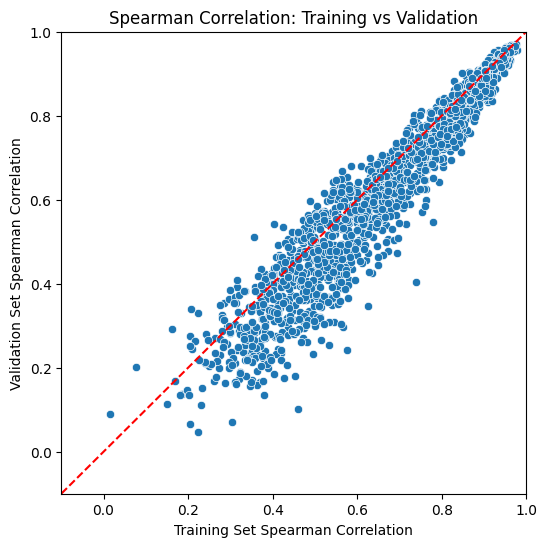

In [5]:
# plot the correlations
plt.figure(figsize=(6, 6))
sns.scatterplot(x='train_corr', y='valid_corr', data=df)
plt.title('Spearman Correlation: Training vs Validation')
plt.xlabel('Training Set Spearman Correlation')
plt.ylabel('Validation Set Spearman Correlation')
plt.plot([-1, 1], [-1, 1], 'r--')
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)
plt.show()

## 6. Save Correlation Summary

Save the comprehensive correlation analysis results to CSV format for downstream analysis and reporting:

### Applications of Saved Results

**Quality Control**:
- Identify genes with poor predictability for exclusion from downstream analysis
- Assess overall Cell2Net performance across the PBMC transcriptome
- Compare performance across different cell types or conditions

**Biological Discovery**:
- High-correlation genes likely have strong regulatory control mechanisms
- Low-correlation genes may represent complex regulatory networks or technical limitations
- Performance patterns may reveal regulatory complexity across immune cell programs

**Method Comparison**:
- Benchmark Cell2Net against other gene expression prediction methods
- Evaluate impact of different feature sets or model architectures
- Assess improvement from pre-training and transfer learning approaches

**Downstream Analysis**:
- Prioritize high-confidence predictions for regulatory network construction
- Filter results for transcription factor analysis and motif enrichment
- Select reliable predictions for experimental validation studies

This systematic evaluation provides the foundation for interpreting Cell2Net results and guides subsequent regulatory genomics analyses.

In [6]:
df.to_csv(f'{out_dir}/gene_correlation.csv', index=False)